### SETUP & IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengunci Random Seed untuk poin Reproducibility (10%)
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### LOAD & EXPLORATORY DATA ANALYSIS (EDA)

Informasi Dataset Train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


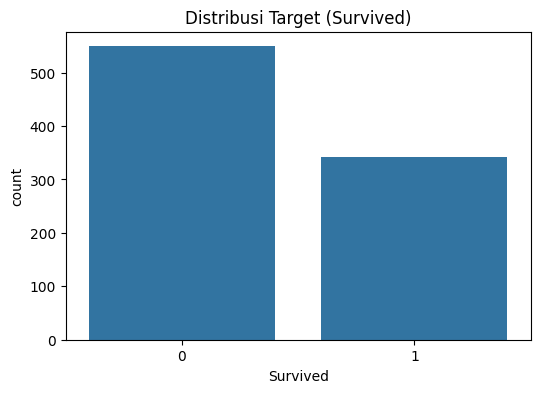

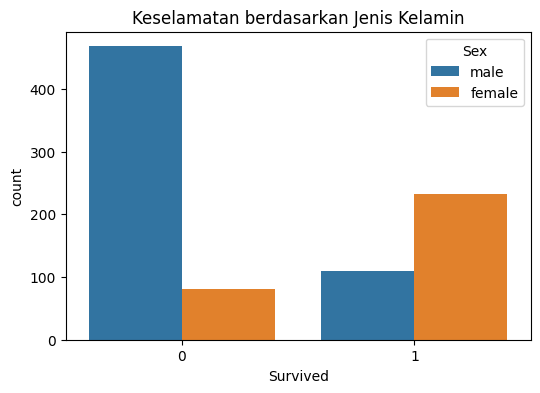

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Informasi Dataset Train:")
print(train_df.info())

# Visualisasi 1: Distribusi Kelas (Selamat vs Tidak)
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_df)
plt.title('Distribusi Target (Survived)')
plt.show()

# Visualisasi 2: Keselamatan berdasarkan Jenis Kelamin
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title('Keselamatan berdasarkan Jenis Kelamin')
plt.show()

In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


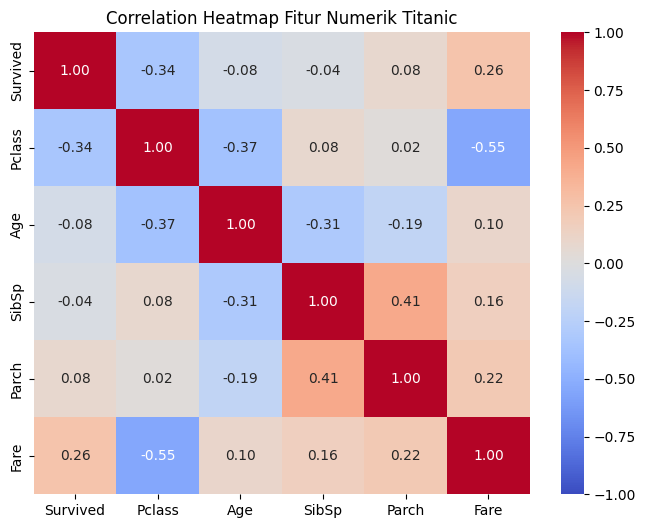

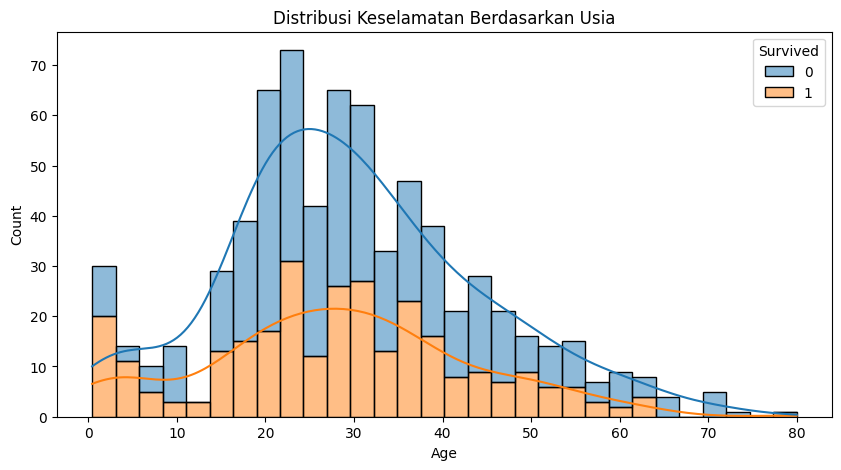

In [ ]:
# 1. Heatmap Korelasi (Hanya untuk fitur numerik dasar)
plt.figure(figsize=(8, 6))
numeric_features = train_df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap Fitur Numerik Titanic')
plt.show()

# 2. Distribusi Usia dan Status Keselamatan
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', bins=30, kde=True)
plt.title('Distribusi Keselamatan Berdasarkan Usia')
plt.show()

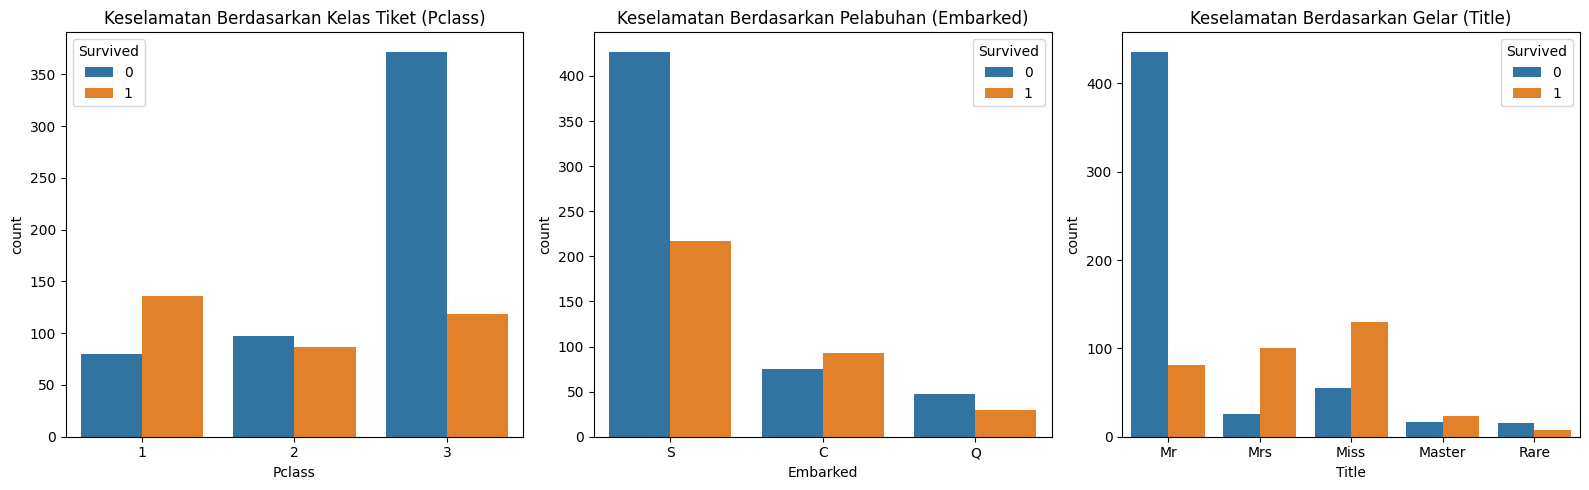

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Pclass vs Survived
sns.countplot(x='Pclass', hue='Survived', data=train_df, ax=axes[0])
axes[0].set_title('Keselamatan Berdasarkan Kelas Tiket (Pclass)')

# 2. Embarked vs Survived
sns.countplot(x='Embarked', hue='Survived', data=train_df, ax=axes[1])
axes[1].set_title('Keselamatan Berdasarkan Pelabuhan (Embarked)')

# 3. Ekstraksi sementara 'Title' untuk visualisasi
temp_df = train_df.copy()
temp_df['Title'] = temp_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Kelompokkan title yang jarang menjadi 'Rare' untuk visualisasi
temp_df['Title'] = temp_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
temp_df['Title'] = temp_df['Title'].replace('Mlle', 'Miss')
temp_df['Title'] = temp_df['Title'].replace('Ms', 'Miss')
temp_df['Title'] = temp_df['Title'].replace('Mme', 'Mrs')

sns.countplot(x='Title', hue='Survived', data=temp_df, ax=axes[2])
axes[2].set_title('Keselamatan Berdasarkan Gelar (Title)')

plt.tight_layout()
plt.show()

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


### ROBUST FEATURE ENGINEERING & PREPROCESSING

In [ ]:
def preprocess_data(df, is_train=True):
    df = df.copy()

    # a. Ekstraksi Title dari Name
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4}
    df['Title'] = df['Title'].map(title_mapping).fillna(0) # 0 untuk gelar langka/rare

    # b. Family Size & IsAlone
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = 1
    df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

    # c. Imputasi Missing Values
    # Imputasi Umur berdasarkan median dari Title
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    # Imputasi Embarked dengan modus
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    # Imputasi Fare dengan median (khusus test set)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # d. Binning Usia & Fare
    df.loc[ df['Age'] <= 16, 'Age'] = 0
    df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
    df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
    df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
    df.loc[ df['Age'] > 64, 'Age'] = 4

    df.loc[ df['Fare'] <= 7.91, 'Fare'] = 0
    df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.454), 'Fare'] = 1
    df.loc[(df['Fare'] > 14.454) & (df['Fare'] <= 31), 'Fare'] = 2
    df.loc[ df['Fare'] > 31, 'Fare'] = 3

    # e. Encoding Kategorikal
    df['Sex'] = df['Sex'].map({'female': 1, 'male': 0}).astype(int)
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

    # g. Drop fitur yang tidak relevan
    drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
    df = df.drop(drop_elements, axis=1)

    return df

train_processed = preprocess_data(train_df, is_train=True)
test_processed = preprocess_data(test_df, is_train=False)

In [ ]:
# ==========================================
# CEK HASIL PREPROCESSING & SCALING
# ==========================================
print("Tampilan Data Train Setelah Preprocessing (5 Baris Pertama):")
display(train_processed.head())

print("\nInfo Data Train Setelah Preprocessing (Pastikan tidak ada null dan semua numerik):")
print(train_processed.info())

Tampilan Data Train Setelah Preprocessing (5 Baris Pertama):


,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,0,1.0,0.0,0,1.0,2,0
1,1,1,1,2.0,3.0,1,3.0,2,0
2,1,3,1,1.0,1.0,0,2.0,1,1
3,1,1,1,2.0,3.0,0,3.0,2,0
4,0,3,0,2.0,1.0,0,1.0,1,1



Info Data Train Setelah Preprocessing (Pastikan tidak ada null dan semua numerik):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    891 non-null    int64  
 6   Title       891 non-null    float64
 7   FamilySize  891 non-null    int64  
 8   IsAlone     891 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 62.8 KB
None


In [ ]:
# KONSISTENSI SPLIT: 80% Train, 20% Validation
X = train_processed.drop('Survived', axis=1)
y = train_processed['Survived']
X_test_sub = test_processed.copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (Sangat penting untuk DL)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_sub_scaled = scaler.transform(X_test_sub)

### BASELINE ML KONVENSIONAL (XGBoost & Random Forest)


--- Model 1: Random Forest ---
RF Training Accuracy   : 0.8399
RF Validation Accuracy : 0.8324

---------- Evaluasi Random Forest ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



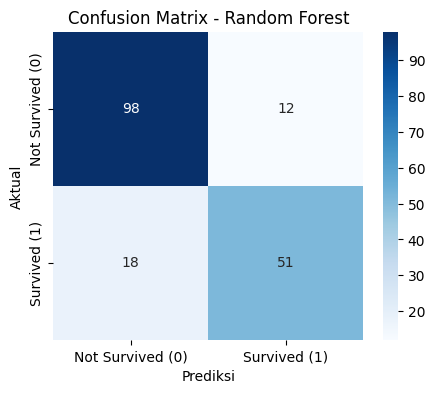


--- Model 2: XGBoost ---
XGB Training Accuracy   : 0.8553
XGB Validation Accuracy : 0.8101

---------- Evaluasi XGBoost ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.75      0.75      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



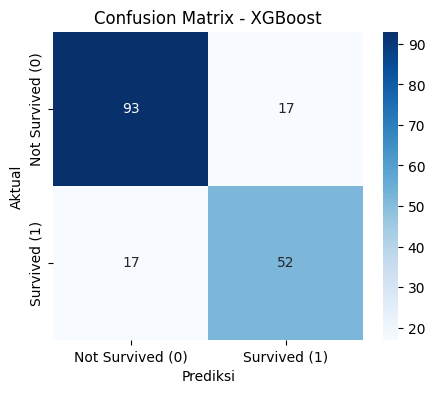

In [ ]:
# ==========================================
# 4. BASELINE ML KONVENSIONAL (XGBoost & RF)
# Termasuk Handling Imbalance & Cek Overfitting
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'-'*10} Evaluasi {model_name} {'-'*10}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Survived (0)', 'Survived (1)'],
                yticklabels=['Not Survived (0)', 'Survived (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

# Menghitung rasio kelas untuk parameter scale_pos_weight XGBoost
# Rasio = jumlah kelas mayoritas (0) / jumlah kelas minoritas (1)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- Model 1: Random Forest ---
# class_weight='balanced' akan otomatis menyesuaikan bobot kelas yang imbalance
print("\n--- Model 1: Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_preds = rf_model.predict(X_train)
rf_val_preds = rf_model.predict(X_val)
rf_probs = rf_model.predict_proba(X_val)[:, 1]

print(f"RF Training Accuracy   : {accuracy_score(y_train, rf_train_preds):.4f}")
print(f"RF Validation Accuracy : {accuracy_score(y_val, rf_val_preds):.4f}")
evaluate_model("Random Forest", y_val, rf_val_preds)

# --- Model 2: XGBoost ---
# scale_pos_weight menangani imbalance secara native di XGBoost
print("\n--- Model 2: XGBoost ---")
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                          random_state=42, use_label_encoder=False, eval_metric='logloss',
                          scale_pos_weight=ratio)
xgb_model.fit(X_train, y_train)

xgb_train_preds = xgb_model.predict(X_train)
xgb_val_preds = xgb_model.predict(X_val)
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

print(f"XGB Training Accuracy   : {accuracy_score(y_train, xgb_train_preds):.4f}")
print(f"XGB Validation Accuracy : {accuracy_score(y_val, xgb_val_preds):.4f}")
evaluate_model("XGBoost", y_val, xgb_val_preds)

### DEEP LEARNING (Multi-Layer Perceptron)


--- Model 3: Deep Learning (MLP) ---
MLP Training Accuracy   : 0.8455
MLP Validation Accuracy : 0.8268

---------- Evaluasi Deep Learning (MLP) ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       110
           1       0.87      0.65      0.74        69

    accuracy                           0.83       179
   macro avg       0.84      0.79      0.81       179
weighted avg       0.83      0.83      0.82       179



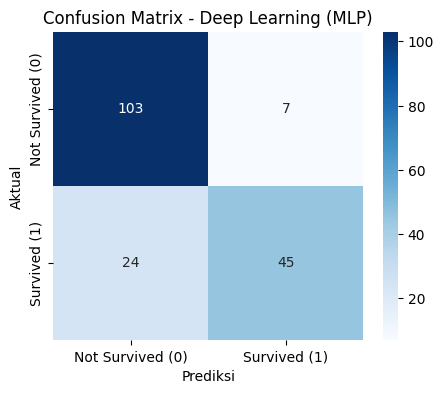

In [ ]:
# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_sub_t = torch.tensor(X_test_sub_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# Arsitektur MLP dengan Dropout untuk mencegah Overfitting di data kecil
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1) # Output raw logits
        )

    def forward(self, x):
        return self.net(x)

dl_model = TabularMLP(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(dl_model.parameters(), lr=0.005, weight_decay=1e-4) # weight_decay = L2 Regularization

print("\n--- Model 3: Deep Learning (MLP) ---")
epochs = 100
for epoch in range(epochs):
    dl_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = dl_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

# ==========================================
# EVALUASI DEEP LEARNING & CEK OVERFITTING
# ==========================================
dl_model.eval()
with torch.no_grad():
    # Prediksi Data Validasi
    val_logits = dl_model(X_val_t)
    dl_probs = torch.sigmoid(val_logits).numpy().flatten()
    dl_preds = (dl_probs > 0.5).astype(int)

    # Prediksi Data Training (untuk cek overfitting)
    train_logits = dl_model(X_train_t)
    train_preds = (torch.sigmoid(train_logits).numpy().flatten() > 0.5).astype(int)

print(f"MLP Training Accuracy   : {accuracy_score(y_train, train_preds):.4f}")
print(f"MLP Validation Accuracy : {accuracy_score(y_val, dl_preds):.4f}")
evaluate_model("Deep Learning (MLP)", y_val, dl_preds)

In [ ]:
from sklearn.metrics import f1_score

print("Mencari Threshold Terbaik untuk MLP...")
best_threshold = 0.5
best_f1 = 0
best_acc = 0

for thresh in np.arange(0.3, 0.7, 0.05):
    preds = (dl_probs > thresh).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    print(f"Threshold: {thresh:.2f} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh
        best_acc = acc

print(f"\nThreshold Optimal: {best_threshold:.2f} dengan Akurasi {best_acc:.4f}")

Mencari Threshold Terbaik untuk MLP...
Threshold: 0.30 | Accuracy: 0.7933 | F1-Score: 0.7613
Threshold: 0.35 | Accuracy: 0.8212 | F1-Score: 0.7778
Threshold: 0.40 | Accuracy: 0.8212 | F1-Score: 0.7538
Threshold: 0.45 | Accuracy: 0.8268 | F1-Score: 0.7438
Threshold: 0.50 | Accuracy: 0.8268 | F1-Score: 0.7438
Threshold: 0.55 | Accuracy: 0.8324 | F1-Score: 0.7458
Threshold: 0.60 | Accuracy: 0.8324 | F1-Score: 0.7458
Threshold: 0.65 | Accuracy: 0.8324 | F1-Score: 0.7458

Threshold Optimal: 0.35 dengan Akurasi 0.8212


### BONUS NILAI TAMBAH: ENSEMBLE (ML + DL)


Mencari Threshold Terbaik untuk Ensemble...
Threshold Optimal Ensemble: 0.40 dengan Akurasi 0.8380 dan F1 0.7943

Ensemble Validation Accuracy (Optimized): 0.8380

---------- Evaluasi Ensemble (RF+XGB+MLP) Optimized ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       110
           1       0.78      0.81      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



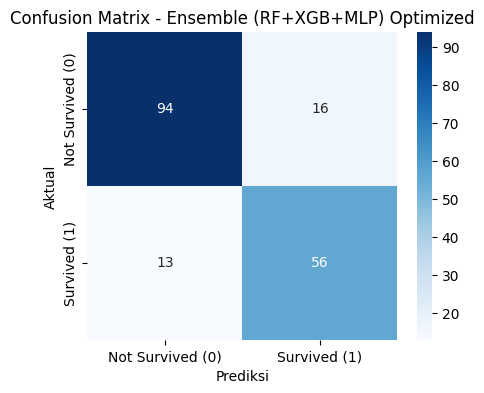

In [ ]:
# Menggabungkan probabilitas dari ketiga model (Soft Voting)
ensemble_probs = (rf_probs + xgb_probs + dl_probs) / 3.0
ensemble_preds = (ensemble_probs > 0.5).astype(int)
print("\nMencari Threshold Terbaik untuk Ensemble...")
best_ens_threshold = 0.5
best_ens_f1 = 0
best_ens_acc = 0

for thresh in np.arange(0.3, 0.7, 0.05):
    preds = (ensemble_probs > thresh).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    if f1 > best_ens_f1:
        best_ens_f1 = f1
        best_ens_threshold = thresh
        best_ens_acc = acc

print(f"Threshold Optimal Ensemble: {best_ens_threshold:.2f} dengan Akurasi {best_ens_acc:.4f} dan F1 {best_ens_f1:.4f}")

# Gunakan Threshold Optimal untuk Prediksi Ensemble di Data Validasi
ensemble_preds = (ensemble_probs > best_ens_threshold).astype(int)

print(f"\nEnsemble Validation Accuracy (Optimized): {accuracy_score(y_val, ensemble_preds):.4f}")
evaluate_model("Ensemble (RF+XGB+MLP) Optimized", y_val, ensemble_preds)

### BONUS NILAI TAMBAH: SUBMIT KAGGLE

In [ ]:
rf_test_probs = rf_model.predict_proba(X_test_sub)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test_sub)[:, 1]

# 2. Prediksi test set dengan MLP
dl_model.eval()
with torch.no_grad():
    dl_test_probs = torch.sigmoid(dl_model(X_test_sub_t)).numpy().flatten()

# 3. Gabungkan hasil prediksi di test set (Probabilitas rata-rata)
ensemble_test_probs = (rf_test_probs + xgb_test_probs + dl_test_probs) / 3.0

# 4. TERAPKAN THRESHOLD OPTIMAL DISINI UNTUK SUBMISSION KAGGLE
final_predictions = (ensemble_test_probs > best_ens_threshold).astype(int)

# 5. Simpan ke CSV
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_predictions
})
submission.to_csv('titanic_ensemble_submission.csv', index=False)